In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import the necessary packages
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
from collections import Counter
from tensorflow.keras.layers import Concatenate

In [2]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large, VGG16
from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtSmall, DenseNet121,ResNet50,InceptionV3,EfficientNetB0
from tensorflow.keras.layers import Input, ReLU, Dense, GlobalAveragePooling2D,Flatten,Dropout,BatchNormalization,SeparableConv2D
from tensorflow.keras.models import Model
from tensorflow import keras
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess_input
from tensorflow.keras.applications.mobilenet import preprocess_input as mob_preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob2_preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess_input
from tensorflow.keras.applications.convnext import preprocess_input as conv_preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess_input
from keras.applications.resnet import preprocess_input as resnet_preprocess_input
from keras.applications.inception_v3 import preprocess_input as inception_preprocess_input

In [3]:
import tensorflow as tf

# Check available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPUs are available:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPUs detected.")

GPUs are available:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [4]:
#read label information
df = pd.read_csv('/kaggle/input/deepweeds/labels.csv')
df.head()

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple


In [5]:
df[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Negative,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,9106,1031,1022,1062,1009,1074,1016


In [6]:
df1_filter= df[df['Species'] != 'Negative']
df1_filter[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,1031,1022,1062,1009,1074,1016


In [7]:
label2id = df[['Species','Label']].groupby(by='Species').min().to_dict()['Label']
id2label = {label2id[i]:i for i in label2id}
id2label

{0: 'Chinee apple',
 1: 'Lantana',
 8: 'Negative',
 2: 'Parkinsonia',
 3: 'Parthenium',
 4: 'Prickly acacia',
 5: 'Rubber vine',
 6: 'Siam weed',
 7: 'Snake weed'}

In [8]:
num_classes = len(df['Label'].unique())
num_classes

9

In [9]:
df1=df[['Filename','Label']]
df1['Label']=df['Label'].astype(int)
df1['Species'] = df1['Label'].map(id2label)
df1.head()

/tmp/ipykernel_23/2892309576.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Label']=df['Label'].astype(int)


,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple


In [10]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df1, test_size=0.3, shuffle=True, random_state=23, stratify=df1['Label'])
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)
len(train), len(test)

(12256, 5253)

In [11]:
df1['Species'].value_counts()

Species
Negative          9106
Chinee apple      1125
Siam weed         1074
Lantana           1064
Prickly acacia    1062
Parkinsonia       1031
Parthenium        1022
Snake weed        1016
Rubber vine       1009
Name: count, dtype: int64

In [12]:
def rescale_to_minus1_1(x):
    return (x / 127.5) - 1.0  # assumes input pixels are in [0, 255]

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    preprocessing_function=rescale_to_minus1_1,
    #rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Set validation split
)

In [14]:
image_size = (224, 224)  # Change based on your model's requirements
batch_size = 64

In [15]:
img_dir='/kaggle/input/deepweeds/images'

In [16]:
# Train Data Generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=img_dir,
    x_col='Filename',
    y_col='Species',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use subset for training
)

Found 9805 validated image filenames belonging to 9 classes.


In [17]:
print("Class indices:", train_generator.class_indices)

Class indices: {'Chinee apple': 0, 'Lantana': 1, 'Negative': 2, 'Parkinsonia': 3, 'Parthenium': 4, 'Prickly acacia': 5, 'Rubber vine': 6, 'Siam weed': 7, 'Snake weed': 8}


In [18]:
# Validation Data Generator
validation_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=img_dir,
    x_col='Filename',
    y_col='Species',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use subset for validation
)

Found 2451 validated image filenames belonging to 9 classes.


In [19]:
print("Class indices:", validation_generator.class_indices)

Class indices: {'Chinee apple': 0, 'Lantana': 1, 'Negative': 2, 'Parkinsonia': 3, 'Parthenium': 4, 'Prickly acacia': 5, 'Rubber vine': 6, 'Siam weed': 7, 'Snake weed': 8}


In [20]:
# Create ImageDataGenerator for test (no augmentation)
test_datagen = ImageDataGenerator(
    #rescale=1./255
    preprocessing_function=rescale_to_minus1_1
    )

In [21]:
# Test Data Generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test,
    directory=img_dir,
    x_col='Filename',
    y_col='Species',  # Assuming test data might still have labels, if not, use None
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',  # Use 'None' if no labels are available
    shuffle=False  # Important for test data to maintain order
)

Found 5253 validated image filenames belonging to 9 classes.


In [22]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers
from tensorflow.keras.applications import efficientnet_v2
seed = 999
tf.random.set_seed(seed)
np.random.seed(seed)
input_shape = image_size + (3,)

def buildModel(train=False):
    # Load the Inception model with weights pre-trained on ImageNet.
    base_model = efficientnet_v2.EfficientNetV2B2(weights='imagenet',include_top=False,input_shape=input_shape)
    base_model.trainable = train
    print("Base Model:", base_model.name)

    # Define the input layer.
    inputs = keras.Input(shape=input_shape)
    x=inputs
    # # Pre-process the input.
    # x = layers.Resizing(224, 224)(inputs)
    # x = layers.Rescaling(1./255)(inputs)
    # #     x = tf.cast(x, tf.float32)
    # #     print("Using Inception Preprocess_Input Layer")
    # #     x = inception_v3.preprocess_input(x)
    
    # ## DAta Augmentation
    # x = layers.RandomBrightness(0.25, (0, 1),seed=seed)(x)
    # x = layers.RandomContrast(0.1, seed=seed)(x)
    # x = layers.GaussianDropout(0.05, seed=seed)(x)
    # x = layers.RandomFlip(seed=seed)(x)
    # x = layers.RandomRotation(0.5, seed=seed)(x)
    # x = layers.RandomTranslation(0.2, 0.2, seed=seed)(x)
    # x = layers.RandomZoom(0.2, 0.2, seed=seed)(x)

    # Pass the input through the pre-trained InceptionV3 model.
    x = base_model(x, training=False)    
    #x = layers.Dropout(0.2)(x) 
    
    ## Add a global average pooling layer.
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Flatten()(x)
    
    outputs = layers.Dense(9, activation='softmax')(x)

    # Create the model.
    model = keras.Model(inputs=inputs, outputs=outputs, name="DeepWeeds-EfficientNetV2B2")
    return model

In [23]:
model = buildModel(train=True)
model.summary()

35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base Model: efficientnetv2-b2


Model: "DeepWeeds-EfficientNetV2B2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b2 (Functional)  │ (None, 7, 7, 1408)     │     8,769,374 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        12,681 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,782,055 (33.50 MB)

 Trainable params: 8,699,767 (33.19 MB)

 Non-trainable params: 82,288 (321.44 KB)

In [24]:
input_shape = image_size + (3,)
input_shape

(224, 224, 3)

In [25]:
from tensorflow.keras import layers, backend as K

def multi_scale_attention(input_feature):
    def spatial_attention(kernel_size):
        avg_pool = layers.Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(input_feature)
        max_pool = layers.Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(input_feature)
        concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
        attention = layers.Conv2D(
            filters=1, 
            kernel_size=kernel_size, 
            strides=1, 
            padding='same', 
            activation='sigmoid')(concat)
        return attention

    # Generate attention maps at different scales
    attn_3 = spatial_attention(3)
    attn_5 = spatial_attention(5)
    attn_7 = spatial_attention(7)

    # Option 1: Multiply each attention map with the input feature
    scaled_3 = layers.Multiply()([input_feature, attn_3])
    scaled_5 = layers.Multiply()([input_feature, attn_5])
    scaled_7 = layers.Multiply()([input_feature, attn_7])

    # Optionally: Concatenate the results
    fused = layers.Concatenate(axis=-1)([scaled_3, scaled_5, scaled_7])

    # Fuse with a Conv layer to reduce dimensionality
    # output = layers.Conv2D(
    #     filters=input_feature.shape[-1], 
    #     kernel_size=1, 
    #     padding='same', 
    #     activation='relu')(fused)

    return fused


In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
import tensorflow.keras.backend as K
# Step 1: Define the Channel Attention Module (CAM)
def channel_attention(input_feature, ratio=8):
    channel_axis = -1
    channels = input_feature.shape[channel_axis]

    # Shared MLP (Multi-Layer Perceptron)
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channels))(avg_pool)
    avg_pool = layers.Dense(channels // ratio, activation='relu')(avg_pool)
    avg_pool = layers.Dense(channels, activation='sigmoid')(avg_pool)
    
    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1, 1, channels))(max_pool)
    max_pool = layers.Dense(channels // ratio, activation='relu')(max_pool)
    max_pool = layers.Dense(channels, activation='sigmoid')(max_pool)

    # Combine the average and max pooling attention
    channel_attention_map = layers.Add()([avg_pool, max_pool])
    channel_attention_map = layers.Multiply()([input_feature, channel_attention_map])
    
    return channel_attention_map

# Step 2: Define the Spatial Attention Module (SAM)
def spatial_attention(input_feature):
    kernel_size = 7
    avg_pool = layers.Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(input_feature)
    max_pool = layers.Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(input_feature)
    
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    spatial_attention_map = layers.Conv2D(filters=1, kernel_size=kernel_size, strides=1, padding='same', activation='sigmoid')(concat)
    spatial_attention_map = layers.Multiply()([input_feature, spatial_attention_map])
    
    return spatial_attention_map


In [27]:
from tensorflow.keras.layers import Conv2D

def atrous_block(input_tensor, filters):
    """
    Atrous convolution block with multiple dilation rates.
    """
    conv_1 = SeparableConv2D(filters, kernel_size=3, dilation_rate=6, padding='same', activation='relu')(input_tensor)
    conv_1 = BatchNormalization()(conv_1)
    conv_1 = ReLU()(conv_1)
    
    conv_2 = SeparableConv2D(filters, kernel_size=3, dilation_rate=12, padding='same', activation='relu')(input_tensor)
    conv_2 = BatchNormalization()(conv_2)
    conv_2 = ReLU()(conv_2)
    
    conv_3 = SeparableConv2D(filters, kernel_size=3, dilation_rate=18, padding='same', activation='relu')(input_tensor)
    conv_3 = BatchNormalization()(conv_3)
    conv_3 = ReLU()(conv_2)

    # Concatenate all the dilated features
    concat = Concatenate(axis=-1)([conv_1, conv_2, conv_3])
    return concat

def spatial_attention_with_atrous(input_feature, filters=256):
    # Apply spatial attention
    attention_refined = spatial_attention(input_feature)

    # Concatenate original + attention-refined
    combined = Concatenate(axis=-1)([input_feature, attention_refined])

    # Apply Atrous convolution block
    atrous_features = atrous_block(combined, filters=filters)

    return atrous_features


In [28]:
model.output

<KerasTensor shape=(None, 9), dtype=float32, sparse=False, name=keras_tensor_353>

In [29]:
# # Extract features from MobileNetV2
# x = base_model.output
# #x = layers.Conv2D(256, (1, 1), activation='relu')(x)  
# #channel_attention_map = channel_attention(x)
    
# # Step 5: Apply Spatial Attention to MobileNetV2 output
# #cbam_map = spatial_attention(channel_attention_map)

# # spatail attention map only
# spatial_attention_map = multi_scale_attention(x)

# #add residual connections
# #output = layers.Add()([x, spatial_attention_map])
# # Step 6: Multiply Channel and Spatial Attention Maps
# #attention_map = layers.Multiply()([channel_attention_map, spatial_attention_map])

# # Step 7: Add the feature from Step 2 (CBAM applied feature) and Step 3 (Attention feature)
# #added_features = layers.Add()([cbam_map, attention_map])
    
# # Step 8: Concatenate the features from Step 1 (MobileNetV2 output) and Step 4 (Added Features)
# concatenated_features = layers.Concatenate(axis=-1)([x, spatial_attention_map])

# #reduce the channel
# #output_feature = Conv2D(256, kernel_size=1, padding='same', activation='relu')(concatenated_features)

# #atrous spatial pooling
# # Apply Atrous convolution block
# atrous_features = atrous_block(concatenated_features, filters=256)

# # Regularization
# #x = BatchNormalization()(output_feature)
# gx = GlobalAveragePooling2D()(atrous_features)
# gx = Dropout(0.4)(gx)
    
# # Fully connected layers for classification
# gx = layers.Dense(128, activation='relu')(gx)
# gx = Dropout(0.3)(gx)
# gx = layers.Dense(num_classes, activation='softmax')(gx)
    
# # Create the final model
# model = models.Model(inputs=base_model.input, outputs=gx)


In [30]:
# # Fully connected layers for classification
# gx=base_model.output
# gx = GlobalAveragePooling2D()(gx)
# #gx = layers.Dense(128, activation='relu')(gx)
# #gx = Dropout(0.3)(gx)
# gx = layers.Dense(num_classes, activation='softmax')(gx)
    
# # Create the final model
# model = models.Model(inputs=base_model.input, outputs=gx)

# model.summary()

In [31]:
# # Global Average Pooling to reduce the feature map size
# x = layers.GlobalAveragePooling2D()(base_model.output)
    
# # Fully connected layers for classification
# x = layers.Dense(128, activation='relu')(x)
# x = layers.Dense(num_classes, activation='softmax')(x)
    
# # Create the final model
# model = models.Model(inputs=base_model.input, outputs=x)
# model.summary()

In [32]:
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
# Constant for epochs
EPOCHS = 50

pat_es = 5
early_stopping = EarlyStopping(monitor='val_loss', patience=pat_es, verbose=1, restore_best_weights=True)
reduce_lr =ReduceLROnPlateau(monitor='val_loss',factor=0.75, patience=pat_es, verbose=1, min_lr=1e-6)

model.compile(loss='categorical_crossentropy',
          optimizer= AdamW(learning_rate=2e-4, weight_decay=3e-2),
          metrics=['accuracy'])

In [33]:
# Define your folder to save results
import os
save_folder = model.name
os.makedirs(save_folder, exist_ok=True)

In [34]:
# filename= 'deepweed'+model.name+'.h5'
# model_weight= os.path.join(save_folder, filename)
# model_weight

In [35]:
%%time
# Train the model
history1 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=[early_stopping, reduce_lr],
    )

Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1745642290.537743      66 service.cc:145] XLA service 0x7feeb8002350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745642290.537801      66 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745642382.886005      66 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_10', 108 bytes spill stores, 164 bytes spill loads
ptxas warning : Registers are spilled to local memory in function '__cuda_sm3x_div_rn_noftz_f32_slowpath', 24 bytes spill stores,

154/154 ━━━━━━━━━━━━━━━━━━━━ 455s 2s/step - accuracy: 0.5265 - loss: 1.4660 - val_accuracy: 0.5667 - val_loss: 1.2663 - learning_rate: 2.0000e-04
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 146s 910ms/step - accuracy: 0.8160 - loss: 0.5574 - val_accuracy: 0.7829 - val_loss: 0.6328 - learning_rate: 2.0000e-04
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 150s 944ms/step - accuracy: 0.8637 - loss: 0.3903 - val_accuracy: 0.3962 - val_loss: 1.7818 - learning_rate: 2.0000e-04
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 148s 929ms/step - accuracy: 0.8964 - loss: 0.3057 - val_accuracy: 0.4933 - val_loss: 1.5845 - learning_rate: 2.0000e-04
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 147s 918ms/step - accuracy: 0.9167 - loss: 0.2427 - val_accuracy: 0.8360 - val_loss: 0.4866 - learning_rate: 2.0000e-04
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 147s 921ms/step - accuracy: 0.9369 - loss: 0.1871 - val_accuracy: 0.8017 - val_loss: 0.6914 - learning_rate: 2.0000e-04
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 146s 912ms/ste

In [36]:
# print("Saving the Model")
# model.save(model_weight)

In [37]:
#image visualization
import matplotlib.pyplot as plt
def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()
    plt.savefig(os.path.join(save_folder, 'training_chart.png'))
    plt.show()

Total Epochs: range(0, 10)


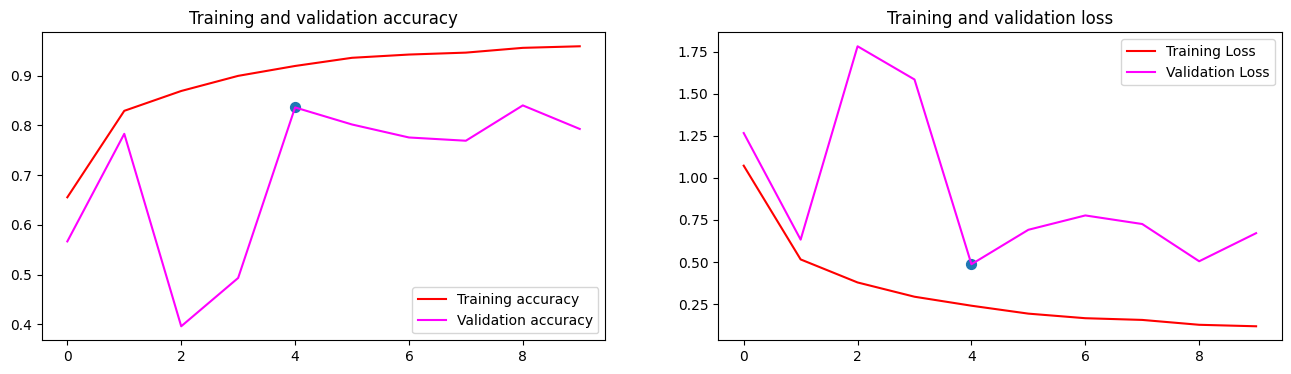

In [38]:
# Plot training results
plot_loss_acc(history1.history)

In [39]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [40]:
predictions=model.predict(test_generator)

83/83 ━━━━━━━━━━━━━━━━━━━━ 61s 670ms/step


In [41]:
import numpy as np
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)
# Get true labels from the test generator
true_labels = test_generator.classes
# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_classes)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[ 155   22   79    0   45    4    0    5   27]
 [   1  288   14    1   11    0    0    3    1]
 [   7   77 2164   21  389   27    9    9   29]
 [   0    0   18  248   24   17    2    0    0]
 [   0    0    4    1  296    5    0    0    1]
 [   0    0   20    3   33  261    1    0    1]
 [   0    4   28    1    1    1  264    0    4]
 [   0   13   15    0    2    0    1  289    2]
 [   3    8   61    1   16    1    2    1  212]]


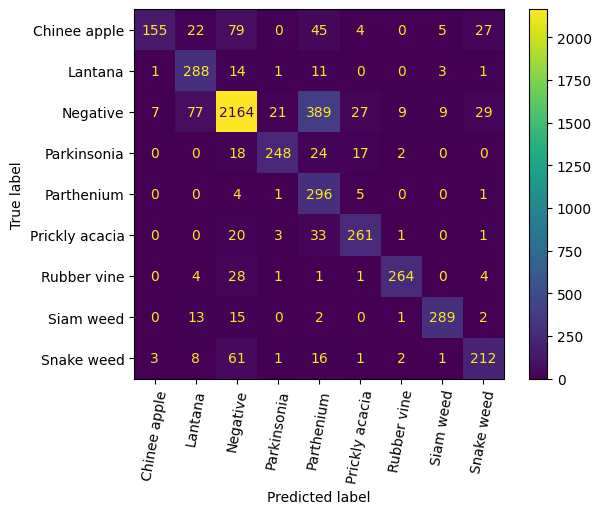

In [42]:
cmd = ConfusionMatrixDisplay.from_predictions(
        true_labels, predicted_classes,
        display_labels=list(test_generator.class_indices.keys()),
        xticks_rotation=80, #'vertical',
        # ax = ax
    )
    # fig, ax = plt.subplots(figsize=(25,5))
    # cmd.plot(ax=ax)
plt.savefig(os.path.join(save_folder, 'confusion-mat.png'))
plt.show()

In [43]:
display_labels=list(test_generator.class_indices.keys())
class_report=classification_report(true_labels, predicted_classes,digits=5, target_names=display_labels)
print(class_report)
with open(os.path.join(save_folder, 'classification_report.txt'), 'w') as f:
    f.write(classification_report(true_labels, predicted_classes))

                precision    recall  f1-score   support

  Chinee apple    0.93373   0.45994   0.61630       337
       Lantana    0.69903   0.90282   0.78796       319
      Negative    0.90054   0.79209   0.84284      2732
   Parkinsonia    0.89855   0.80259   0.84786       309
    Parthenium    0.36230   0.96417   0.52669       307
Prickly acacia    0.82595   0.81818   0.82205       319
   Rubber vine    0.94624   0.87129   0.90722       303
     Siam weed    0.94137   0.89752   0.91892       322
    Snake weed    0.76534   0.69508   0.72852       305

      accuracy                        0.79516      5253
     macro avg    0.80812   0.80041   0.77760      5253
  weighted avg    0.85162   0.79516   0.80727      5253

